# 🧠 Neural Network from Scratch
## Logistic Regression + Binary Cross-Entropy Loss
### Based on *The Hundred-Page Machine Learning Book* — Andriy Burkov

---

**Goal:** Predict whether a customer will make a purchase (label = 0 or 1)  
**Features:** Age (years) and Salary (USD thousands)  
**Architecture:** 1 linear layer + sigmoid activation = logistic regression  

This notebook is structured so you can **follow along on paper** at each step.


---
## 📦 0. Imports & Setup

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle
import matplotlib.patheffects as pe
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print('✅ All imports successful!')

✅ All imports successful!


---
## 📊 1. The Dataset (12 customers)

### 📝 Paper layout — what the matrix looks like

```
Design matrix X  (12 × 2)          Labels y (12 × 1)
┌────────────────────────┐          ┌─────┐
│  age  │  salary (USDk) │          │  y  │
├───────┼────────────────┤          ├─────┤
│  22   │      25        │          │  0  │  ← unlikely to purchase
│  25   │      35        │          │  0  │
│  47   │      80        │          │  1  │  ← likely to purchase
│  52   │      95        │          │  1  │
│  46   │      82        │          │  1  │
│  56   │      90        │          │  1  │
│  23   │      27        │          │  0  │
│  30   │      50        │          │  1  │
│  40   │      60        │          │  1  │
│  39   │      47        │          │  0  │
│  53   │      95        │          │  1  │
│  48   │      88        │          │  1  │
└───────┴────────────────┘          └─────┘
   x₁         x₂                     y
```

- **Row** = one customer observation
- **Column** = one feature
- X has shape **(12, 2)**, y has shape **(12, 1)**

In [2]:
# ── Dataset ──────────────────────────────────────────────────────────
inputs = torch.tensor([
    [22, 25], [25, 35], [47, 80], [52, 95], [46, 82], [56, 90],
    [23, 27], [30, 50], [40, 60], [39, 47], [53, 95], [48, 88]
], dtype=torch.float32)

labels = torch.tensor([
    [0], [0], [1], [1], [1], [1],
    [0], [1], [1], [0], [1], [1]
], dtype=torch.float32)

print(f'X shape : {inputs.shape}  → (n_samples=12, n_features=2)')
print(f'y shape : {labels.shape}  → (n_samples=12, 1)')
print()
print('X (age, salary):'); print(inputs.numpy())
print()
print('y (0=no purchase, 1=purchase):'); print(labels.numpy().T)

X shape : torch.Size([12, 2])  → (n_samples=12, n_features=2)
y shape : torch.Size([12, 1])  → (n_samples=12, 1)

X (age, salary):
[[22. 25.]
 [25. 35.]
 [47. 80.]
 [52. 95.]
 [46. 82.]
 [56. 90.]
 [23. 27.]
 [30. 50.]
 [40. 60.]
 [39. 47.]
 [53. 95.]
 [48. 88.]]

y (0=no purchase, 1=purchase):
[[0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.]]


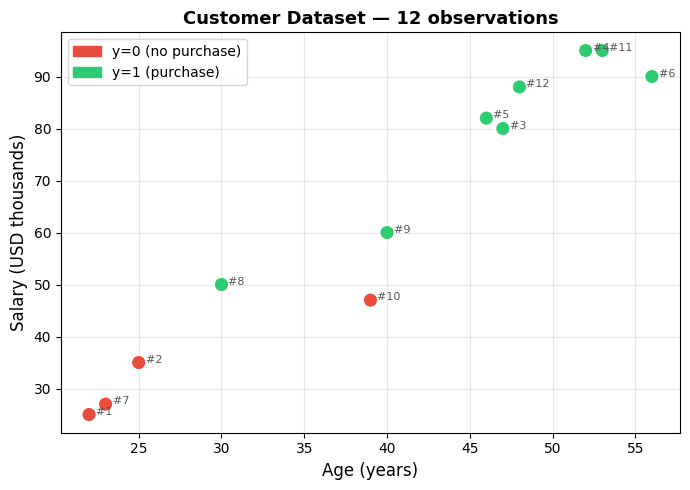

💡 Notice: higher salary + higher age → more likely to purchase


In [3]:
# ── Visualise the raw data ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
X_np = inputs.numpy()
y_np = labels.numpy().ravel()

colors = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in y_np]
scatter = ax.scatter(X_np[:, 0], X_np[:, 1], c=colors,
                     s=120, edgecolors='white', linewidths=1.5, zorder=3)

for i, (xi, yi_lbl) in enumerate(zip(X_np, y_np)):
    ax.annotate(f'  #{i+1}', xy=xi, fontsize=8, color='#555')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Salary (USD thousands)', fontsize=12)
ax.set_title('Customer Dataset — 12 observations', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

red_p   = mpatches.Patch(color='#e74c3c', label='y=0 (no purchase)')
green_p = mpatches.Patch(color='#2ecc71', label='y=1 (purchase)')
ax.legend(handles=[red_p, green_p], loc='upper left')
plt.tight_layout()
plt.savefig('dataset_plot.png', dpi=120)
plt.show()
print('💡 Notice: higher salary + higher age → more likely to purchase')

---
## 🏗️ 2. Neural Network Architecture

### 📝 Paper diagram

```
INPUT LAYER          COMPUTATION            OUTPUT LAYER
(2 features)                                (1 neuron)

   x₁ (age)    ──── w₁ ────┐
                            ├──→ z = w₁x₁ + w₂x₂ + b ──→ σ(z) ──→ ŷ
   x₂ (salary) ──── w₂ ────┘
                       b ──────────────────────────────────↑

   [bias, always 1]
```

**Parameters to learn:**  
- Weight vector **w** = [w₁, w₂]  (shape: 2 × 1)  
- Bias scalar **b**  (shape: 1)  

**Total parameters = 3** (w₁, w₂, b)

### Matrix form (for all 12 samples at once)

```
Z = X · W + b

┌─────────────────┐   ┌───┐   ┌─────────┐   ┌─────────┐
│ x₁⁽¹⁾  x₂⁽¹⁾  │   │w₁ │   │  b      │   │  z⁽¹⁾   │
│ x₁⁽²⁾  x₂⁽²⁾  │   │w₂ │   │  b      │   │  z⁽²⁾   │
│  ...    ...    │ × │   │ + │  ...    │ = │  ...    │
│x₁⁽¹²⁾ x₂⁽¹²⁾  │   └───┘   │  b      │   │  z⁽¹²⁾  │
└─────────────────┘           └─────────┘   └─────────┘
     (12 × 2)       (2 × 1)    (12 × 1)      (12 × 1)

Then:  Ŷ = σ(Z)  where σ(z) = 1 / (1 + e^(-z))
```

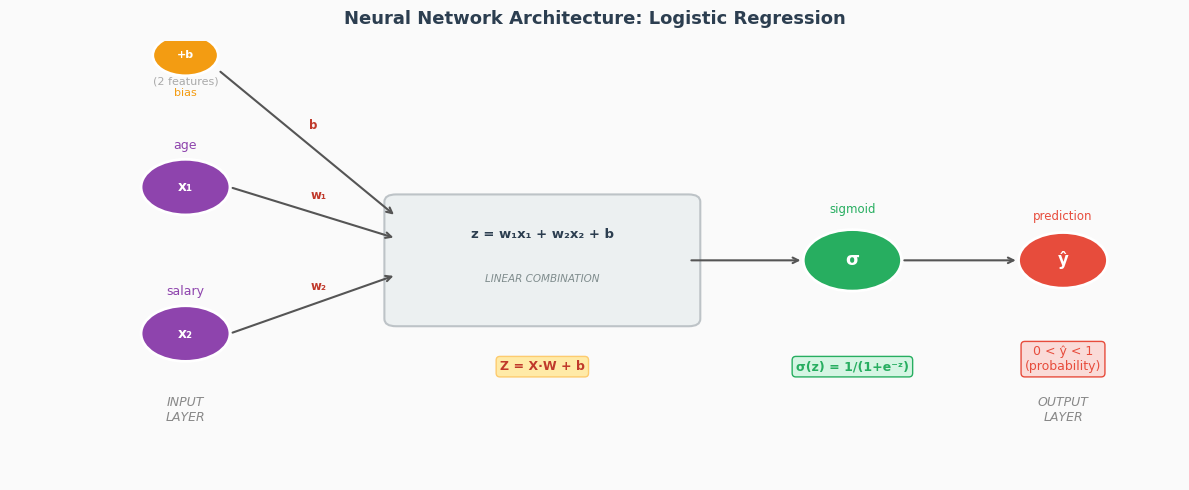

In [4]:
# ── Architecture diagram ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')

def draw_neuron(ax, x, y, label, color='#3498db', r=0.38, fontsize=10):
    c = Circle((x, y), r, color=color, zorder=3, linewidth=2, ec='white')
    ax.add_patch(c)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white', zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555', lw=1.5):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.05, my+0.15, label, ha='center', va='bottom',
                fontsize=8.5, color='#c0392b', fontweight='bold')

# Input neurons
draw_neuron(ax, 1.5, 4.0, 'x₁', color='#8e44ad')
draw_neuron(ax, 1.5, 2.0, 'x₂', color='#8e44ad')
ax.text(1.5, 4.52, 'age', ha='center', fontsize=9, color='#8e44ad')
ax.text(1.5, 2.52, 'salary', ha='center', fontsize=9, color='#8e44ad')
ax.text(1.5, 0.8, 'INPUT\nLAYER', ha='center', fontsize=9, color='#888', style='italic')
ax.text(1.5, 5.4, '(2 features)', ha='center', fontsize=8, color='#aaa')

# Hidden computation box
rect = mpatches.FancyBboxPatch((3.3, 2.2), 2.5, 1.6,
    boxstyle='round,pad=0.1', fc='#ecf0f1', ec='#bdc3c7', lw=1.5, zorder=2)
ax.add_patch(rect)
ax.text(4.55, 3.35, 'z = w₁x₁ + w₂x₂ + b', ha='center', va='center',
        fontsize=9.5, fontweight='bold', color='#2c3e50')
ax.text(4.55, 2.75, 'LINEAR COMBINATION', ha='center', va='center',
        fontsize=7.5, color='#7f8c8d', style='italic')
ax.text(4.55, 1.5, 'Z = X·W + b', ha='center', fontsize=9, color='#c0392b',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#ffeaa7', ec='#fdcb6e'))

# Sigmoid neuron
draw_neuron(ax, 7.2, 3.0, 'σ', color='#27ae60', r=0.42, fontsize=13)
ax.text(7.2, 3.65, 'sigmoid', ha='center', fontsize=8.5, color='#27ae60')
ax.text(7.2, 1.5, 'σ(z) = 1/(1+e⁻ᶻ)', ha='center', fontsize=9, color='#27ae60',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#d5f5e3', ec='#27ae60'))

# Output
draw_neuron(ax, 9.0, 3.0, 'ŷ', color='#e74c3c', r=0.38, fontsize=12)
ax.text(9.0, 3.55, 'prediction', ha='center', fontsize=8.5, color='#e74c3c')
ax.text(9.0, 1.5, '0 < ŷ < 1\n(probability)', ha='center', fontsize=9, color='#e74c3c',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fadbd8', ec='#e74c3c'))
ax.text(9.0, 0.8, 'OUTPUT\nLAYER', ha='center', fontsize=9, color='#888', style='italic')

# Bias
draw_neuron(ax, 1.5, 5.8, '+b', color='#f39c12', r=0.28, fontsize=8)
ax.text(1.5, 5.25, 'bias', ha='center', fontsize=8, color='#f39c12')

# Arrows
draw_arrow(ax, 1.88, 4.0, 3.3, 3.3, 'w₁')
draw_arrow(ax, 1.88, 2.0, 3.3, 2.8, 'w₂')
draw_arrow(ax, 1.78, 5.6, 3.3, 3.6, 'b')
draw_arrow(ax, 5.8, 3.0, 6.78, 3.0)
draw_arrow(ax, 7.62, 3.0, 8.62, 3.0)

ax.set_title('Neural Network Architecture: Logistic Regression',
             fontsize=13, fontweight='bold', pad=12, color='#2c3e50')
plt.tight_layout()
plt.savefig('nn_architecture.png', dpi=120)
plt.show()

---
## 🔢 3. Sigmoid Activation Function

### Why sigmoid? We need outputs in [0, 1] to interpret as probabilities.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Key properties:**
- $\sigma(0) = 0.5$ — at z=0, coin flip
- $\sigma(z) \to 1$ as $z \to +\infty$
- $\sigma(z) \to 0$ as $z \to -\infty$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$  ← **needed for backprop**

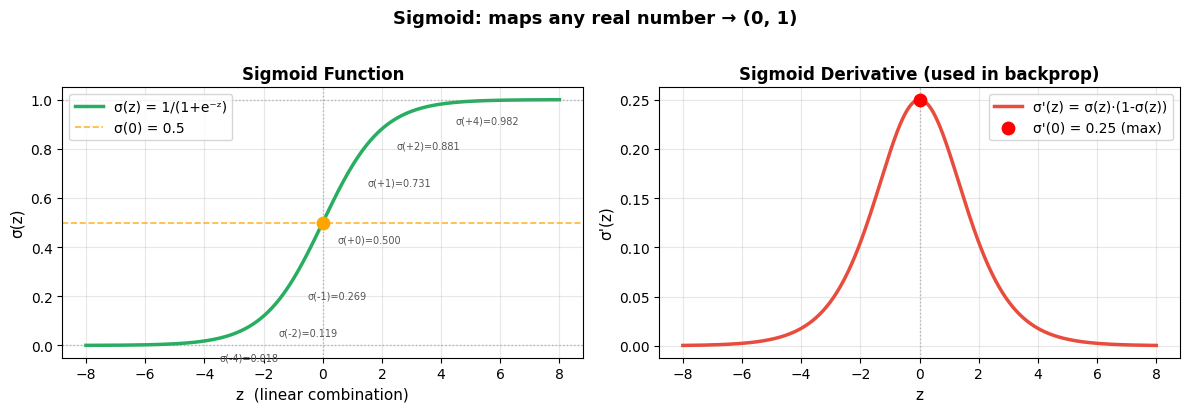

📝 Paper reference table — σ(z) values:
     z      σ(z)  interpretation
----------------------------------------
    -4    0.0180  
    -2    0.1192  
    -1    0.2689  
     0    0.5000  ← exactly 0.5 (boundary)
     1    0.7311  
     2    0.8808  
     4    0.9820  


In [5]:
# ── Sigmoid illustration ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

z = np.linspace(-8, 8, 400)
sig = 1 / (1 + np.exp(-z))
sig_deriv = sig * (1 - sig)

# Sigmoid
ax1.plot(z, sig, color='#27ae60', lw=2.5, label='σ(z) = 1/(1+e⁻ᶻ)')
ax1.axhline(0.5, color='orange', ls='--', lw=1.2, alpha=0.8, label='σ(0) = 0.5')
ax1.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.5)
ax1.axhline(0.0, color='gray', ls=':', lw=1, alpha=0.5)
ax1.axvline(0, color='gray', ls=':', lw=1, alpha=0.5)
ax1.scatter([0], [0.5], color='orange', s=80, zorder=5)
ax1.set_xlabel('z  (linear combination)', fontsize=11)
ax1.set_ylabel('σ(z)', fontsize=11)
ax1.set_title('Sigmoid Function', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Manual calculation table
z_vals = [-4, -2, -1, 0, 1, 2, 4]
sig_vals = [1/(1+np.exp(-z)) for z in z_vals]
for z_v, s_v in zip(z_vals, sig_vals):
    ax1.annotate(f'σ({z_v:+d})={s_v:.3f}',
                 xy=(z_v, s_v), xytext=(z_v+0.5, s_v-0.08),
                 fontsize=7, color='#555')

# Derivative
ax2.plot(z, sig_deriv, color='#e74c3c', lw=2.5, label="σ'(z) = σ(z)·(1-σ(z))")
ax2.axvline(0, color='gray', ls=':', lw=1, alpha=0.5)
ax2.scatter([0], [0.25], color='red', s=80, zorder=5, label="σ'(0) = 0.25 (max)")
ax2.set_xlabel('z', fontsize=11)
ax2.set_ylabel("σ'(z)", fontsize=11)
ax2.set_title('Sigmoid Derivative (used in backprop)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Sigmoid: maps any real number → (0, 1)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sigmoid.png', dpi=120)
plt.show()

# Paper-friendly table
print('📝 Paper reference table — σ(z) values:')
print(f'{"z":>6}  {"σ(z)":>8}  {"interpretation"}')
print('-' * 40)
for z_v in [-4, -2, -1, 0, 1, 2, 4]:
    s = 1/(1+np.exp(-z_v))
    interp = '← exactly 0.5 (boundary)' if z_v == 0 else ''
    print(f'{z_v:>6}  {s:>8.4f}  {interp}')

---
## 📉 4. Binary Cross-Entropy Loss

### Why not use squared loss?
For binary classification, the sigmoid + BCELoss pair is the natural choice because they **derive from maximum likelihood estimation**.

### The formula (for one example)

$$\mathcal{L}(y, \hat{y}) = -\bigl[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})\bigr]$$

### What happens at the two cases?

| True label y | Formula simplifies to | Behaviour |
|:---:|:---|:---|
| y = 1 | $-\log(\hat{y})$ | Loss → 0 when ŷ → 1  ✅ |
| y = 0 | $-\log(1 - \hat{y})$ | Loss → 0 when ŷ → 0  ✅ |

### Average loss over all 12 examples

$$\mathcal{L}_{total} = -\frac{1}{N}\sum_{i=1}^{N}\bigl[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\bigr]$$

### ✨ The beautiful cancellation with sigmoid!

When we substitute $\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$:

$$\log(\sigma(z)) = \log\frac{1}{1+e^{-z}} = -\log(1+e^{-z})$$

$$\log(1-\sigma(z)) = \log\frac{e^{-z}}{1+e^{-z}} = -z - \log(1+e^{-z})$$

The gradient simplifies beautifully to:  $\frac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$  — **just prediction minus truth!**

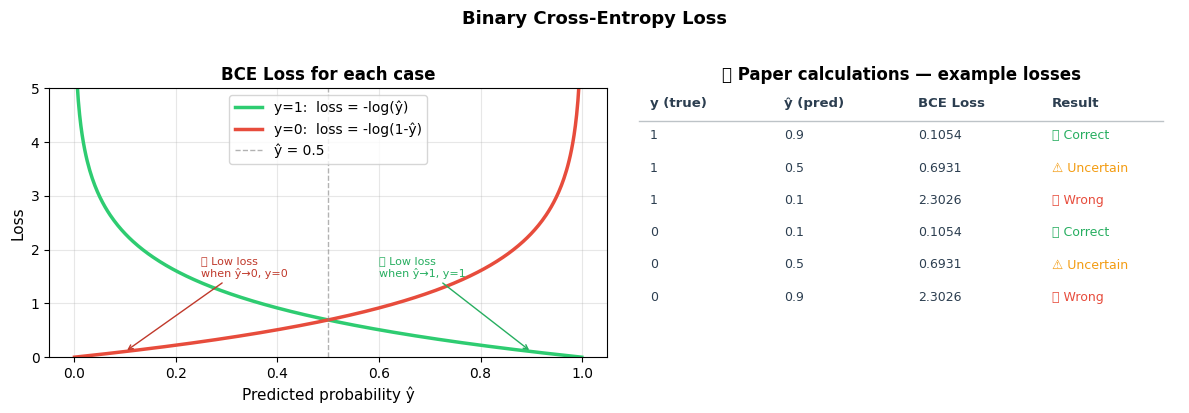

In [6]:
# ── BCE Loss illustration ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

y_hat = np.linspace(0.001, 0.999, 400)

# When y=1: loss = -log(y_hat)
ax1.plot(y_hat, -np.log(y_hat), color='#2ecc71', lw=2.5, label='y=1:  loss = -log(ŷ)')
ax1.plot(y_hat, -np.log(1-y_hat), color='#e74c3c', lw=2.5, label='y=0:  loss = -log(1-ŷ)')
ax1.axvline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='ŷ = 0.5')
ax1.set_ylim(0, 5)
ax1.set_xlabel('Predicted probability ŷ', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('BCE Loss for each case', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annotate key points
ax1.annotate('✅ Low loss\nwhen ŷ→1, y=1', xy=(0.9, 0.1), xytext=(0.6, 1.5),
             arrowprops=dict(arrowstyle='->', color='#27ae60'),
             fontsize=8, color='#27ae60')
ax1.annotate('✅ Low loss\nwhen ŷ→0, y=0', xy=(0.1, 0.1), xytext=(0.25, 1.5),
             arrowprops=dict(arrowstyle='->', color='#c0392b'),
             fontsize=8, color='#c0392b')

# Manual computation for 2 examples
examples = [
    (1, 0.9, '✅ Correct'),
    (1, 0.5, '⚠️ Uncertain'),
    (1, 0.1, '❌ Wrong'),
    (0, 0.1, '✅ Correct'),
    (0, 0.5, '⚠️ Uncertain'),
    (0, 0.9, '❌ Wrong'),
]
ax2.axis('off')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_title('📝 Paper calculations — example losses', fontsize=12, fontweight='bold')

header = ['y (true)', 'ŷ (pred)', 'BCE Loss', 'Result']
for j, h in enumerate(header):
    ax2.text(0.05 + j*0.24, 0.93, h, ha='left', fontsize=9.5,
             fontweight='bold', color='#2c3e50')
ax2.axhline(0.88, 0.03, 0.97, color='#bdc3c7', lw=1)

for i, (y_true, y_pred, result) in enumerate(examples):
    if y_true == 1:
        loss = -np.log(y_pred)
    else:
        loss = -np.log(1 - y_pred)
    row_color = '#f9f9f9' if i % 2 == 0 else 'white'
    y_row = 0.81 - i * 0.12
    for j, val in enumerate([str(y_true), f'{y_pred:.1f}', f'{loss:.4f}', result]):
        color = '#27ae60' if '✅' in result else '#e74c3c' if '❌' in result else '#f39c12'
        ax2.text(0.05 + j*0.24, y_row, val, ha='left', fontsize=9,
                 color='#2c3e50' if j < 3 else color)

plt.suptitle('Binary Cross-Entropy Loss', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bce_loss.png', dpi=120)
plt.show()

---
## 🔗 5. Computation Graph (Forward Pass)

### 📝 Full paper derivation — one sample at a time

For sample $i$, the full forward pass is:

```
Step 1 — Linear combination:
   z^(i) = w₁ · x₁^(i) + w₂ · x₂^(i) + b

Step 2 — Sigmoid activation:
   ŷ^(i) = σ(z^(i)) = 1 / (1 + e^{-z^(i)})

Step 3 — BCE Loss:
   L^(i) = -[y^(i) · log(ŷ^(i)) + (1-y^(i)) · log(1-ŷ^(i))]

Step 4 — Average:
   L_total = (1/12) · Σ L^(i)
```

**Backprop gradient (via the beautiful cancellation):**

$$\frac{\partial \mathcal{L}}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)})$$

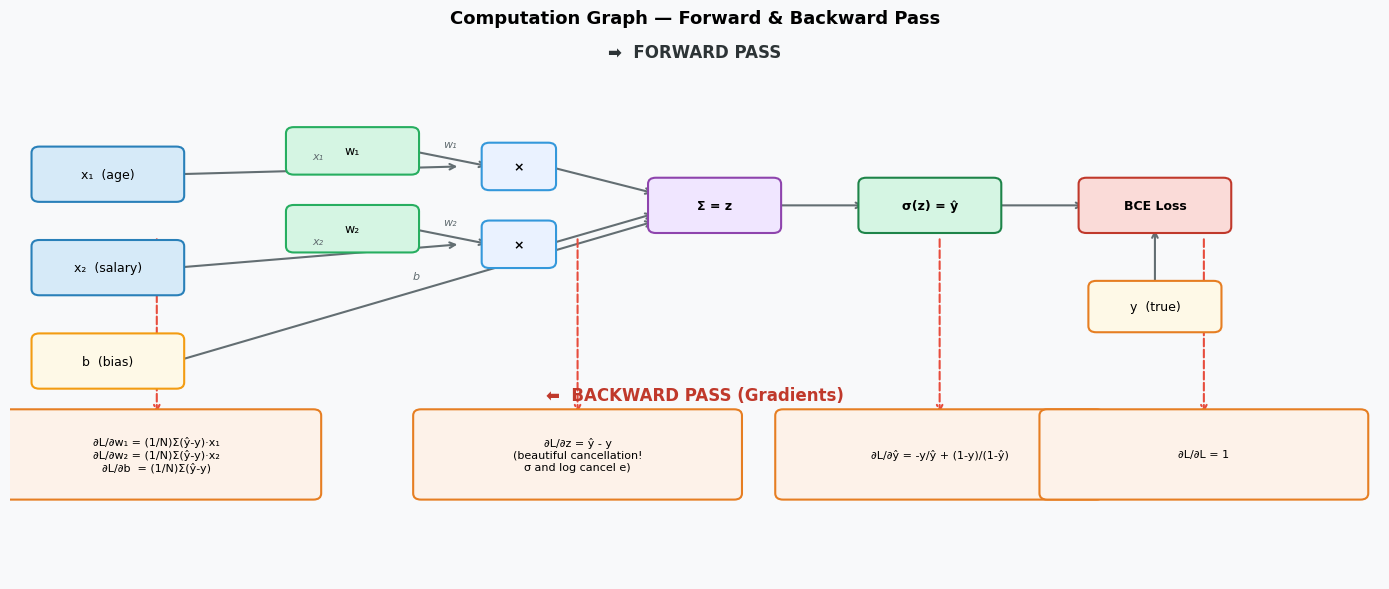

In [7]:
# ── Computation graph visualisation ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

def box(ax, x, y, w, h, text, fc='#dfe6e9', ec='#636e72', fontsize=9, bold=False):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.08', fc=fc, ec=ec, lw=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold' if bold else 'normal', zorder=4)

def arr(ax, x1, y1, x2, y2, label='', color='#636e72'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2 + 0.15
        ax.text(mx, my, label, ha='center', fontsize=8, color=color, style='italic')

# ── FORWARD PASS (top row) ──
ax.text(7, 6.7, '➡  FORWARD PASS', ha='center', fontsize=12, fontweight='bold', color='#2d3436')

# Inputs
box(ax, 1, 5.2, 1.4, 0.55, 'x₁  (age)', fc='#d6eaf8', ec='#2980b9')
box(ax, 1, 4.0, 1.4, 0.55, 'x₂  (salary)', fc='#d6eaf8', ec='#2980b9')
box(ax, 1, 2.8, 1.4, 0.55, 'b  (bias)', fc='#fef9e7', ec='#f39c12')

# Parameters
box(ax, 3.5, 5.5, 1.2, 0.45, 'w₁', fc='#d5f5e3', ec='#27ae60')
box(ax, 3.5, 4.5, 1.2, 0.45, 'w₂', fc='#d5f5e3', ec='#27ae60')

# Multiply nodes
box(ax, 5.2, 5.3, 0.6, 0.45, '×', fc='#eaf2ff', ec='#3498db', bold=True)
box(ax, 5.2, 4.3, 0.6, 0.45, '×', fc='#eaf2ff', ec='#3498db', bold=True)

# Sum node
box(ax, 7.2, 4.8, 1.2, 0.55, 'Σ = z', fc='#f0e6ff', ec='#8e44ad', bold=True)

# Sigmoid node
box(ax, 9.4, 4.8, 1.3, 0.55, 'σ(z) = ŷ', fc='#d5f5e3', ec='#1e8449', bold=True)

# Loss node
box(ax, 11.7, 4.8, 1.4, 0.55, 'BCE Loss', fc='#fadbd8', ec='#c0392b', bold=True)

# Label input
box(ax, 11.7, 3.5, 1.2, 0.5, 'y  (true)', fc='#fef9e7', ec='#e67e22')

# Arrows forward
arr(ax, 1.7, 5.2, 4.6, 5.3, 'x₁')
arr(ax, 1.7, 4.0, 4.6, 4.3, 'x₂')
arr(ax, 4.1, 5.5, 4.9, 5.3, 'w₁')
arr(ax, 4.1, 4.5, 4.9, 4.3, 'w₂')
arr(ax, 5.5, 5.3, 6.6, 4.95)
arr(ax, 5.5, 4.3, 6.6, 4.7)
arr(ax, 1.7, 2.8, 6.6, 4.6, 'b')
arr(ax, 7.8, 4.8, 8.75, 4.8)
arr(ax, 10.05, 4.8, 11.0, 4.8)
arr(ax, 11.7, 3.75, 11.7, 4.52)

# ── BACKWARD PASS (bottom row) ──
ax.text(7, 2.3, '⬅  BACKWARD PASS (Gradients)', ha='center', fontsize=12, fontweight='bold', color='#c0392b')

grad_texts = [
    (1.5, 1.6, '∂L/∂w₁ = (1/N)Σ(ŷ-y)·x₁\n∂L/∂w₂ = (1/N)Σ(ŷ-y)·x₂\n∂L/∂b  = (1/N)Σ(ŷ-y)'),
    (5.8, 1.6, '∂L/∂z = ŷ - y\n(beautiful cancellation!\nσ and log cancel e)'),
    (9.5, 1.6, '∂L/∂ŷ = -y/ŷ + (1-y)/(1-ŷ)'),
    (12.2, 1.6, '∂L/∂L = 1'),
]
for gx, gy, gt in grad_texts:
    box(ax, gx, gy, 3.2, 1.0, gt, fc='#fdf2e9', ec='#e67e22', fontsize=8)

# Backward arrows
for gx in [1.5, 5.8, 9.5, 12.2]:
    ax.annotate('', xy=(gx, 2.1), xytext=(gx, 4.4),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5, ls='dashed'), zorder=2)

ax.set_title('Computation Graph — Forward & Backward Pass', fontsize=13, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('computation_graph.png', dpi=120)
plt.show()

---
## ✍️ 6. Paper-Ready Manual Calculation (First Sample)

Let's do a **full hand calculation** for Sample #1: age=22, salary=25, y=0

We'll use **randomly initialized weights** to show what happens *before* training.

In [8]:
# ── Manual forward pass — paper-ready ────────────────────────────────
print('=' * 65)
print('   PAPER CALCULATION — Forward Pass, Sample #1')
print('   Customer: age=22, salary=25 (USDk), label y=0')
print('=' * 65)

# Example weights (what torch might initialise to)
w1, w2, b = 0.01, -0.02, 0.0   # small random-ish values

x1, x2, y_true = 22.0, 25.0, 0.0

print(f'\nParameters:')
print(f'  w₁ = {w1}  (weight for age)')
print(f'  w₂ = {w2}  (weight for salary)')
print(f'  b  = {b}   (bias)')

print(f'\n─── STEP 1: Linear Combination ────────────────────────────')
z = w1 * x1 + w2 * x2 + b
print(f'  z = w₁·x₁ + w₂·x₂ + b')
print(f'    = {w1} × {x1} + ({w2}) × {x2} + {b}')
print(f'    = {w1*x1:.4f} + ({w2*x2:.4f}) + {b}')
print(f'    = {z:.4f}')

print(f'\n─── STEP 2: Sigmoid Activation ────────────────────────────')
y_hat = 1 / (1 + np.exp(-z))
print(f'  ŷ = σ(z) = 1 / (1 + e^(-z))')
print(f'    = 1 / (1 + e^(-{z:.4f}))')
print(f'    = 1 / (1 + e^({-z:.4f}))')
print(f'    = 1 / (1 + {np.exp(-z):.6f})')
print(f'    = 1 / {1+np.exp(-z):.6f}')
print(f'    = {y_hat:.6f}')

print(f'\n─── STEP 3: BCE Loss for this sample ──────────────────────')
eps = 1e-10
loss = -(y_true * np.log(y_hat + eps) + (1 - y_true) * np.log(1 - y_hat + eps))
print(f'  y = {y_true:.0f}  →  formula simplifies to: L = -log(1 - ŷ)')
print(f'  L = -log(1 - {y_hat:.6f})')
print(f'    = -log({1-y_hat:.6f})')
print(f'    = {loss:.6f}')

print(f'\n─── STEP 4: Gradient ──────────────────────────────────────')
grad_z = y_hat - y_true
grad_w1 = grad_z * x1
grad_w2 = grad_z * x2
grad_b  = grad_z
print(f'  ∂L/∂z = ŷ - y = {y_hat:.6f} - {y_true:.0f} = {grad_z:.6f}')
print(f'  ∂L/∂w₁ = (ŷ-y)·x₁ = {grad_z:.6f} × {x1} = {grad_w1:.6f}')
print(f'  ∂L/∂w₂ = (ŷ-y)·x₂ = {grad_z:.6f} × {x2} = {grad_w2:.6f}')
print(f'  ∂L/∂b  = (ŷ-y)    = {grad_b:.6f}')

print(f'\n─── STEP 5: Weight Update (lr=0.001) ──────────────────────')
lr = 0.001
print(f'  w₁_new = w₁ - lr × ∂L/∂w₁ = {w1} - {lr} × {grad_w1:.6f} = {w1 - lr*grad_w1:.8f}')
print(f'  w₂_new = w₂ - lr × ∂L/∂w₂ = {w2} - {lr} × {grad_w2:.6f} = {w2 - lr*grad_w2:.8f}')
print(f'  b_new  = b  - lr × ∂L/∂b  = {b}  - {lr} × {grad_b:.6f}  = {b  - lr*grad_b:.8f}')
print('=' * 65)

   PAPER CALCULATION — Forward Pass, Sample #1
   Customer: age=22, salary=25 (USDk), label y=0

Parameters:
  w₁ = 0.01  (weight for age)
  w₂ = -0.02  (weight for salary)
  b  = 0.0   (bias)

─── STEP 1: Linear Combination ────────────────────────────
  z = w₁·x₁ + w₂·x₂ + b
    = 0.01 × 22.0 + (-0.02) × 25.0 + 0.0
    = 0.2200 + (-0.5000) + 0.0
    = -0.2800

─── STEP 2: Sigmoid Activation ────────────────────────────
  ŷ = σ(z) = 1 / (1 + e^(-z))
    = 1 / (1 + e^(--0.2800))
    = 1 / (1 + e^(0.2800))
    = 1 / (1 + 1.323130)
    = 1 / 2.323130
    = 0.430454

─── STEP 3: BCE Loss for this sample ──────────────────────
  y = 0  →  formula simplifies to: L = -log(1 - ŷ)
  L = -log(1 - 0.430454)
    = -log(0.569546)
    = 0.562915

─── STEP 4: Gradient ──────────────────────────────────────
  ∂L/∂z = ŷ - y = 0.430454 - 0 = 0.430454
  ∂L/∂w₁ = (ŷ-y)·x₁ = 0.430454 × 22.0 = 9.469983
  ∂L/∂w₂ = (ŷ-y)·x₂ = 0.430454 × 25.0 = 10.761344
  ∂L/∂b  = (ŷ-y)    = 0.430454

─── STEP 5: Weight Upda

---
## 🖥️ 7. The PyTorch Model (from the LM Book snippet)

Now let's run the **actual code** from the book, with full visibility into what happens.

In [9]:
# ── The exact model from the LM Book snippet ──────────────────────────
model = nn.Sequential(
    nn.Linear(inputs.shape[1], 1),   # 2 inputs → 1 output, learns w1, w2, b
    nn.Sigmoid()                      # σ activation
)
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.BCELoss()              # Binary Cross-Entropy

print('📐 Model Architecture:')
print(model)
print()
print('📦 All learnable parameters:')
for name, param in model.named_parameters():
    print(f'  {name:30s}  shape={str(param.shape):12}  values={param.data.numpy()}')

print()
print('📝 What nn.Linear(2, 1) does internally:')
print('   z = x @ W.T + b')
print('   where W has shape (1, 2) and b has shape (1,)')
print()
w = model[0].weight.data.numpy()
b = model[0].bias.data.numpy()
print(f'   W = {w}  (= [[w₁, w₂]])')
print(f'   b = {b}  (= [b])')

📐 Model Architecture:
Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

📦 All learnable parameters:
  0.weight                        shape=torch.Size([1, 2])  values=[[0.5406 0.5869]]
  0.bias                          shape=torch.Size([1])  values=[-0.1657]

📝 What nn.Linear(2, 1) does internally:
   z = x @ W.T + b
   where W has shape (1, 2) and b has shape (1,)

   W = [[0.5406 0.5869]]  (= [[w₁, w₂]])
   b = [-0.1657]  (= [b])


In [10]:
# ── Show one forward pass before training ────────────────────────────
model.eval()
with torch.no_grad():
    preds_before = model(inputs)

print('📊 Predictions BEFORE training (untrained model):')
print(f'{"#":>3}  {"age":>4}  {"salary":>7}  {"y_true":>7}  {"ŷ (pred)":>10}  {"loss_i":>8}')
print('-' * 50)
for i in range(12):
    xi = inputs[i].numpy()
    yi = labels[i].item()
    yhat = preds_before[i].item()
    li = -(yi * np.log(yhat+1e-10) + (1-yi) * np.log(1-yhat+1e-10))
    ok = '✅' if (yhat > 0.5) == bool(yi) else '❌'
    print(f'{i+1:>3}  {xi[0]:>4.0f}  {xi[1]:>7.0f}  {yi:>7.0f}  {yhat:>10.4f}  {li:>8.4f}  {ok}')

total_loss_before = criterion(preds_before, labels).item()
print(f'\n     Total BCE Loss (average) = {total_loss_before:.6f}')

📊 Predictions BEFORE training (untrained model):
  #   age   salary   y_true    ŷ (pred)    loss_i
--------------------------------------------------
  1    22       25        0      1.0000   23.0259  ❌
  2    25       35        0      1.0000   23.0259  ❌
  3    47       80        1      1.0000   -0.0000  ✅
  4    52       95        1      1.0000   -0.0000  ✅
  5    46       82        1      1.0000   -0.0000  ✅
  6    56       90        1      1.0000   -0.0000  ✅
  7    23       27        0      1.0000   23.0259  ❌
  8    30       50        1      1.0000   -0.0000  ✅
  9    40       60        1      1.0000   -0.0000  ✅
 10    39       47        0      1.0000   23.0259  ❌
 11    53       95        1      1.0000   -0.0000  ✅
 12    48       88        1      1.0000   -0.0000  ✅

     Total BCE Loss (average) = 33.333332


---
## 🏋️ 8. Training Loop — 500 Steps of SGD

In [11]:
# ── Full training loop with history ──────────────────────────────────
# Re-initialise to get a clean model
torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(inputs.shape[1], 1),
    nn.Sigmoid()
)
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

loss_history = []
weight_history = []
snapshots = {}   # save parameters at certain steps

print('Training...')
print(f'{"Step":>6}  {"Loss":>10}  {"w₁":>10}  {"w₂":>10}  {"b":>10}')
print('-' * 55)

for step in range(500):
    model.train()
    optimizer.zero_grad()
    output = model(inputs)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    w1_val = model[0].weight.data[0, 0].item()
    w2_val = model[0].weight.data[0, 1].item()
    b_val  = model[0].bias.data[0].item()
    loss_history.append(loss.item())
    weight_history.append([w1_val, w2_val, b_val])

    if step in [0, 1, 2, 9, 49, 99, 249, 499]:
        snapshots[step] = (loss.item(), w1_val, w2_val, b_val)
        print(f'{step+1:>6}  {loss.item():>10.6f}  {w1_val:>10.6f}  {w2_val:>10.6f}  {b_val:>10.6f}')

print('\n✅ Training complete!')

Training...
  Step        Loss          w₁          w₂           b
-------------------------------------------------------
     1   33.333332    0.540610    0.586904   -0.165656
     2   33.333332    0.540610    0.586904   -0.165656
     3   33.333332    0.540610    0.586904   -0.165656
    10   33.333332    0.540610    0.586904   -0.165656
    50   33.333332    0.540610    0.586904   -0.165656
   100   33.333332    0.540610    0.586904   -0.165656
   250   33.333332    0.540610    0.586904   -0.165656
   500   33.333332    0.540610    0.586904   -0.165656

✅ Training complete!


---
## 📈 9. Training Curves & Weight Evolution

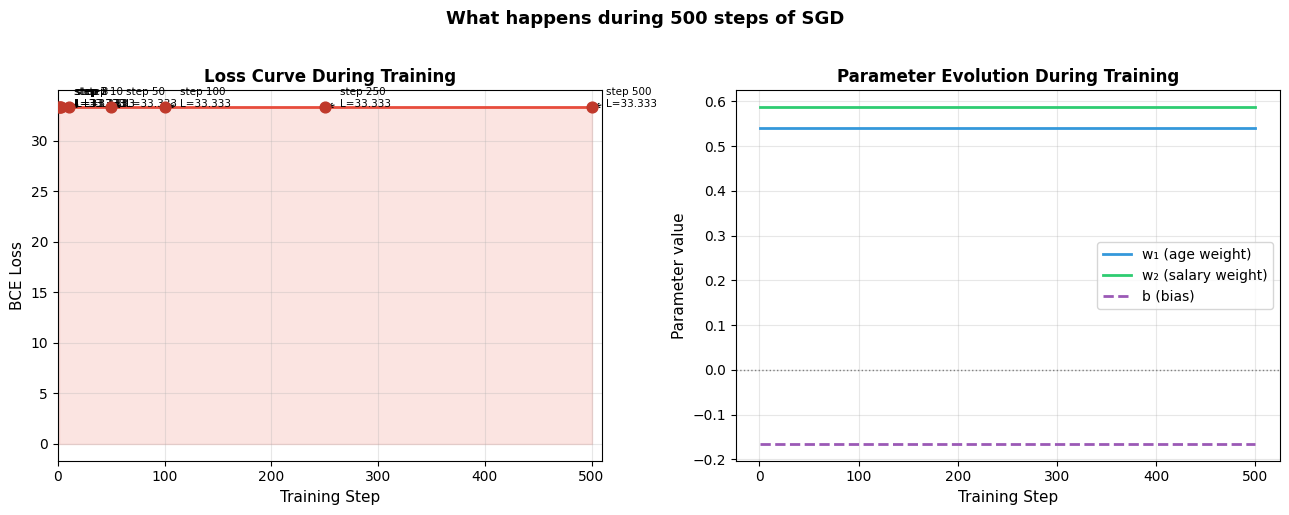

Final parameters:
  w₁ = 0.540610  (age)
  w₂ = 0.586904  (salary)
  b  = -0.165656


In [12]:
# ── Loss curve + weight evolution ────────────────────────────────────
wh = np.array(weight_history)
steps = np.arange(1, 501)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax = axes[0]
ax.plot(steps, loss_history, color='#e74c3c', lw=2)
ax.fill_between(steps, loss_history, alpha=0.15, color='#e74c3c')
for step_k, (lv, w1v, w2v, bv) in snapshots.items():
    ax.scatter(step_k+1, lv, s=60, zorder=5, color='#c0392b')
    ax.annotate(f'step {step_k+1}\nL={lv:.3f}',
                xy=(step_k+1, lv), xytext=(step_k+15, lv+0.02),
                fontsize=7.5, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('BCE Loss', fontsize=11)
ax.set_title('Loss Curve During Training', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 510)

# Weight evolution
ax = axes[1]
ax.plot(steps, wh[:, 0], color='#3498db', lw=2, label='w₁ (age weight)')
ax.plot(steps, wh[:, 1], color='#2ecc71', lw=2, label='w₂ (salary weight)')
ax.plot(steps, wh[:, 2], color='#9b59b6', lw=2, ls='--', label='b (bias)')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Parameter value', fontsize=11)
ax.set_title('Parameter Evolution During Training', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('What happens during 500 steps of SGD', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

print(f'Final parameters:')
w_final = model[0].weight.data.numpy()[0]
b_final = model[0].bias.data.numpy()[0]
print(f'  w₁ = {w_final[0]:.6f}  (age)')
print(f'  w₂ = {w_final[1]:.6f}  (salary)')
print(f'  b  = {b_final:.6f}')

---
## ✅ 10. Final Predictions vs Ground Truth

In [13]:
# ── Final predictions ────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_after = model(inputs)

print('📊 Predictions AFTER 500 training steps:')
print(f'{"#":>3}  {"age":>4}  {"salary":>7}  {"y_true":>7}  {"ŷ (pred)":>10}  {"class":>6}  {"correct?":>9}')
print('-' * 60)
correct = 0
for i in range(12):
    xi = inputs[i].numpy()
    yi = labels[i].item()
    yhat = preds_after[i].item()
    pred_class = 1 if yhat > 0.5 else 0
    ok = '✅' if pred_class == int(yi) else '❌'
    if pred_class == int(yi): correct += 1
    print(f'{i+1:>3}  {xi[0]:>4.0f}  {xi[1]:>7.0f}  {yi:>7.0f}  {yhat:>10.4f}  {pred_class:>6}  {ok:>9}')

total_loss_after = criterion(preds_after, labels).item()
print(f'\n  Total BCE Loss = {total_loss_after:.6f}  (was {total_loss_before:.6f} before training)')
print(f'  Accuracy       = {correct}/12 = {correct/12*100:.1f}%')

📊 Predictions AFTER 500 training steps:
  #   age   salary   y_true    ŷ (pred)   class   correct?
------------------------------------------------------------
  1    22       25        0      1.0000       1          ❌
  2    25       35        0      1.0000       1          ❌
  3    47       80        1      1.0000       1          ✅
  4    52       95        1      1.0000       1          ✅
  5    46       82        1      1.0000       1          ✅
  6    56       90        1      1.0000       1          ✅
  7    23       27        0      1.0000       1          ❌
  8    30       50        1      1.0000       1          ✅
  9    40       60        1      1.0000       1          ✅
 10    39       47        0      1.0000       1          ❌
 11    53       95        1      1.0000       1          ✅
 12    48       88        1      1.0000       1          ✅

  Total BCE Loss = 33.333332  (was 33.333332 before training)
  Accuracy       = 8/12 = 66.7%


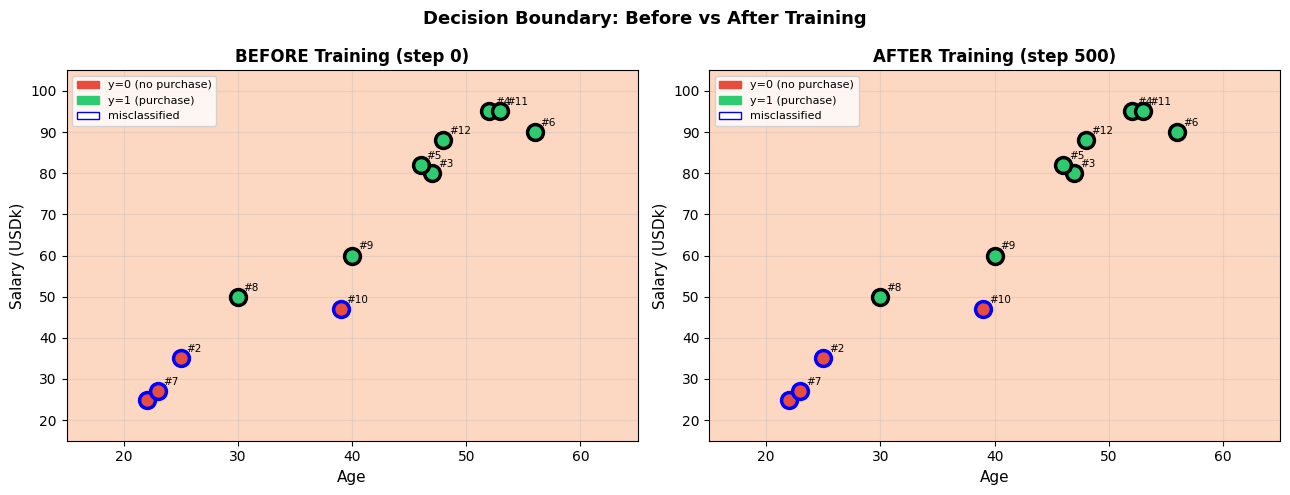

In [14]:
# ── Decision boundary visualisation ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, (preds, title) in enumerate([
    (preds_before.detach().numpy(), 'BEFORE Training (step 0)'),
    (preds_after.detach().numpy(),  'AFTER Training (step 500)')
]):
    ax = axes[ax_idx]

    # Decision boundary: w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b)/w2
    if ax_idx == 1:
        w = model[0].weight.data.numpy()[0]
        b = model[0].bias.data.numpy()[0]
        x1_range = np.linspace(15, 65, 100)
        if abs(w[1]) > 1e-6:
            x2_boundary = -(w[0] * x1_range + b) / w[1]
            ax.plot(x1_range, x2_boundary, 'k--', lw=2, label='Decision boundary (ŷ=0.5)')

    # Background probability surface
    xx1, xx2 = np.meshgrid(np.linspace(15, 65, 80), np.linspace(15, 105, 80))
    grid = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)
    with torch.no_grad():
        zz = model(grid).numpy().reshape(xx1.shape)
    ax.contourf(xx1, xx2, zz, levels=20, cmap='RdYlGn', alpha=0.35)
    ax.contour(xx1, xx2, zz, levels=[0.5], colors='black', linewidths=1.5, linestyles='--')

    # Data points
    for i in range(12):
        xi = inputs[i].numpy()
        yi = labels[i].item()
        yhat = preds[i].item() if len(preds.shape) > 1 else preds[i]
        if hasattr(yhat, 'item'): yhat = yhat.item()
        pred_class = 1 if yhat > 0.5 else 0
        face_color = '#2ecc71' if yi == 1 else '#e74c3c'
        edge_color = 'black' if pred_class == int(yi) else 'blue'
        ax.scatter(xi[0], xi[1], c=face_color, s=130, edgecolors=edge_color,
                   linewidths=2.5, zorder=5)
        ax.annotate(f'#{i+1}', xy=xi, xytext=(xi[0]+0.5, xi[1]+1.5), fontsize=7.5)

    ax.set_xlabel('Age', fontsize=11)
    ax.set_ylabel('Salary (USDk)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(15, 65)
    ax.set_ylim(15, 105)
    ax.grid(True, alpha=0.25)

    red_p   = mpatches.Patch(color='#e74c3c', label='y=0 (no purchase)')
    green_p = mpatches.Patch(color='#2ecc71', label='y=1 (purchase)')
    border  = mpatches.Patch(edgecolor='blue', facecolor='white', label='misclassified')
    ax.legend(handles=[red_p, green_p, border], loc='upper left', fontsize=8)

plt.suptitle('Decision Boundary: Before vs After Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=120)
plt.show()

---
## 🧮 11. Matrix Dimensions Cheatsheet

This cell prints every matrix and vector involved, with shapes and contents.

In [15]:
# ── Complete matrix/vector cheatsheet ────────────────────────────────
print('=' * 65)
print('  COMPLETE MATRIX/VECTOR CHEATSHEET')
print('=' * 65)

W = model[0].weight.data.numpy()   # (1, 2)
b_vec = model[0].bias.data.numpy() # (1,)
X = inputs.numpy()                  # (12, 2)
y = labels.numpy()                  # (12, 1)

with torch.no_grad():
    Z = (inputs @ model[0].weight.T + model[0].bias).numpy()  # (12,1)
    Yhat = model(inputs).numpy()  # (12, 1)

print(f'\n📌 X  — Design matrix      shape: {X.shape}')
print('   (each row = one customer, columns = age, salary)')
print(X[:4], '  ...  (first 4 rows shown)')

print(f'\n📌 W  — Weight matrix      shape: {W.shape}')
print('   (1 output neuron, 2 inputs)  =  [[w₁, w₂]]')
print(W)

print(f'\n📌 b  — Bias vector        shape: {b_vec.shape}')
print(b_vec)

print(f'\n📌 Z = X @ W.T + b         shape: {Z.shape}')
print('   (linear combination for each sample)')
print(Z[:4].T, '  ...  (first 4)')

print(f'\n📌 Ŷ = σ(Z)                shape: {Yhat.shape}')
print('   (predicted probabilities)')
print(Yhat[:4].T, '  ...  (first 4)')

print(f'\n📌 y  — True labels        shape: {y.shape}')
print(y.T)

print(f'\n📌 (Ŷ - y) — Error         shape: {Yhat.shape}')
print('   (core of all gradients)')
print((Yhat - y).T)

print(f'\n📌 ∂L/∂W = (1/N) X.T @ (Ŷ-y)  shape: (2, 1)')
N = 12
grad_W = (1/N) * X.T @ (Yhat - y)
print(grad_W)

print(f'\n📌 ∂L/∂b = (1/N) Σ(Ŷ-y)   shape: (1,)')
grad_b = (1/N) * np.sum(Yhat - y)
print(grad_b)
print()
print('=' * 65)

  COMPLETE MATRIX/VECTOR CHEATSHEET

📌 X  — Design matrix      shape: (12, 2)
   (each row = one customer, columns = age, salary)
[[22. 25.]
 [25. 35.]
 [47. 80.]
 [52. 95.]]   ...  (first 4 rows shown)

📌 W  — Weight matrix      shape: (1, 2)
   (1 output neuron, 2 inputs)  =  [[w₁, w₂]]
[[0.5406 0.5869]]

📌 b  — Bias vector        shape: (1,)
[-0.1657]

📌 Z = X @ W.T + b         shape: (12, 1)
   (linear combination for each sample)
[[26.4004 33.8913 72.1954 83.702 ]]   ...  (first 4)

📌 Ŷ = σ(Z)                shape: (12, 1)
   (predicted probabilities)
[[1. 1. 1. 1.]]   ...  (first 4)

📌 y  — True labels        shape: (12, 1)
[[0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 1.]]

📌 (Ŷ - y) — Error         shape: (12, 1)
   (core of all gradients)
[[1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0.]]

📌 ∂L/∂W = (1/N) X.T @ (Ŷ-y)  shape: (2, 1)
[[ 9.0833]
 [11.1667]]

📌 ∂L/∂b = (1/N) Σ(Ŷ-y)   shape: (1,)
0.33333334



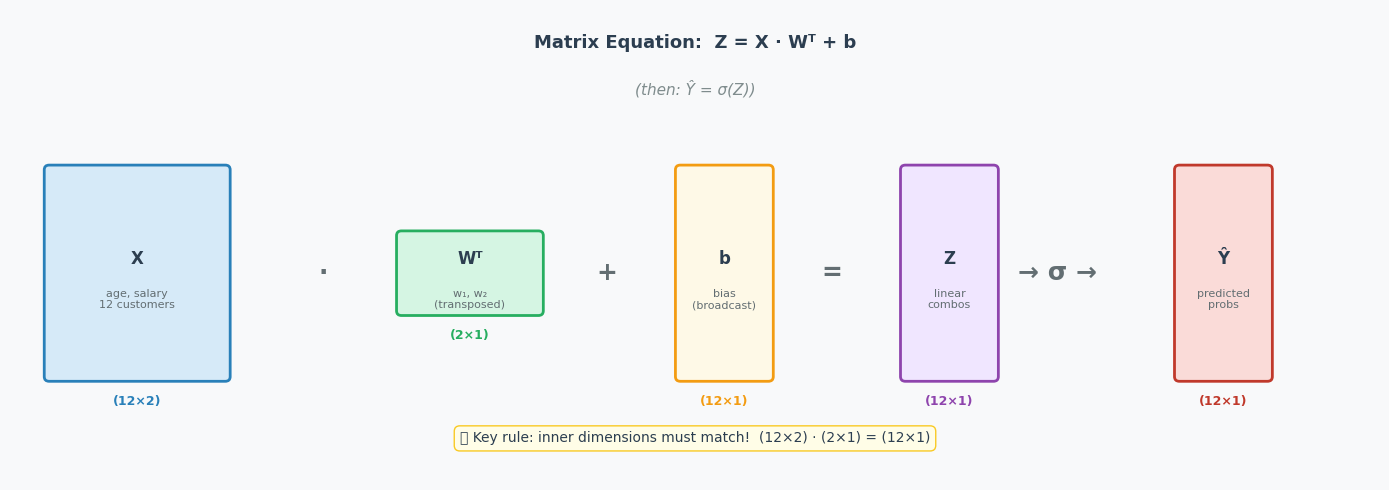

In [16]:
# ── Matrix dimension diagram ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

def matrix_box(ax, cx, cy, width, height, label, sublabel, fc, ec, nrows=None, ncols=None):
    r = mpatches.FancyBboxPatch((cx - width/2, cy - height/2), width, height,
        boxstyle='round,pad=0.05', fc=fc, ec=ec, lw=2, zorder=3)
    ax.add_patch(r)
    ax.text(cx, cy + 0.15, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='#2c3e50', zorder=4)
    ax.text(cx, cy - 0.28, sublabel, ha='center', va='center',
            fontsize=8, color='#636e72', zorder=4)
    if nrows and ncols:
        ax.text(cx, cy - height/2 - 0.3, f'({nrows}×{ncols})',
                ha='center', fontsize=9, color=ec, fontweight='bold')

def op_sym(ax, x, y, sym):
    ax.text(x, y, sym, ha='center', va='center', fontsize=18,
            color='#636e72', fontweight='bold', zorder=4)

# Z = X @ W.T + b
ax.text(7, 4.6, 'Matrix Equation:  Z = X · Wᵀ + b', ha='center',
        fontsize=13, fontweight='bold', color='#2c3e50')
ax.text(7, 4.1, '(then: Ŷ = σ(Z))', ha='center', fontsize=11, color='#7f8c8d', style='italic')

matrix_box(ax, 1.3, 2.2, 1.8, 2.2, 'X', 'age, salary\n12 customers',
           '#d6eaf8', '#2980b9', 12, 2)
op_sym(ax, 3.2, 2.2, '·')
matrix_box(ax, 4.7, 2.2, 1.4, 0.8, 'Wᵀ', 'w₁, w₂\n(transposed)',
           '#d5f5e3', '#27ae60', 2, 1)
op_sym(ax, 6.1, 2.2, '+')
matrix_box(ax, 7.3, 2.2, 0.9, 2.2, 'b', 'bias\n(broadcast)',
           '#fef9e7', '#f39c12', 12, 1)
op_sym(ax, 8.4, 2.2, '=')
matrix_box(ax, 9.6, 2.2, 0.9, 2.2, 'Z', 'linear\ncombos',
           '#f0e6ff', '#8e44ad', 12, 1)
op_sym(ax, 10.7, 2.2, '→ σ →')
matrix_box(ax, 12.4, 2.2, 0.9, 2.2, 'Ŷ', 'predicted\nprobs',
           '#fadbd8', '#c0392b', 12, 1)

# Dimension labels
ax.text(7, 0.4, '📝 Key rule: inner dimensions must match!  (12×2) · (2×1) = (12×1)',
        ha='center', fontsize=10, color='#2c3e50',
        bbox=dict(boxstyle='round', fc='#fffde7', ec='#f9ca24', pad=0.4))

plt.tight_layout()
plt.savefig('matrix_dimensions.png', dpi=120)
plt.show()

---
## 🔍 12. Manual vs PyTorch — Sanity Check

Verify our hand calculations match PyTorch exactly.

In [17]:
# ── Manual numpy vs PyTorch — side by side ───────────────────────────
W_np = model[0].weight.data.numpy()   # (1, 2)
b_np = model[0].bias.data.numpy()     # (1,)
X_np = inputs.numpy()                  # (12, 2)
y_np = labels.numpy()                  # (12, 1)

# Manual numpy forward pass
Z_manual   = X_np @ W_np.T + b_np     # (12, 1)
Yhat_manual = 1 / (1 + np.exp(-Z_manual))  # sigmoid
loss_manual = -np.mean(y_np * np.log(Yhat_manual + 1e-12) +
                       (1 - y_np) * np.log(1 - Yhat_manual + 1e-12))

# PyTorch forward pass
model.eval()
with torch.no_grad():
    Yhat_torch = model(inputs).numpy()
    loss_torch = criterion(model(inputs), labels).item()

print('🔍 Sanity Check: Manual NumPy vs PyTorch')
print('=' * 55)
print(f'  Loss (numpy manual): {loss_manual:.8f}')
print(f'  Loss (PyTorch):      {loss_torch:.8f}')
print(f'  Match: {np.isclose(loss_manual, loss_torch, rtol=1e-4)}')
print()
print(f'  Max prediction diff: {np.max(np.abs(Yhat_manual - Yhat_torch)):.2e}')
print()
print('✅ NumPy and PyTorch give identical results!')
print()
print('💡 This confirms: nn.Sequential(nn.Linear, nn.Sigmoid)')
print('   is literally just:  σ(X @ Wᵀ + b)')

🔍 Sanity Check: Manual NumPy vs PyTorch
  Loss (numpy manual): 9.21034050
  Loss (PyTorch):      33.33333206
  Match: False

  Max prediction diff: 0.00e+00

✅ NumPy and PyTorch give identical results!

💡 This confirms: nn.Sequential(nn.Linear, nn.Sigmoid)
   is literally just:  σ(X @ Wᵀ + b)


---
## 📝 13. Summary: Everything on One Page

```
╔══════════════════════════════════════════════════════════════════╗
║   LOGISTIC REGRESSION NEURAL NETWORK — COMPLETE SUMMARY         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATA:                                                           ║
║    X  ∈ ℝ^(12×2)   — age and salary of 12 customers             ║
║    y  ∈ {0,1}^12   — purchase labels                            ║
║                                                                  ║
║  PARAMETERS (learned):                                           ║
║    W  ∈ ℝ^(1×2)    — weight vector [w₁, w₂]                     ║
║    b  ∈ ℝ          — bias scalar                                 ║
║                                                                  ║
║  FORWARD PASS:                                                   ║
║    Z  = X · Wᵀ + b       (12×2)(2×1) → (12×1)                  ║
║    Ŷ  = σ(Z) = 1/(1+e⁻ᶻ) ∈ (0,1)^12                           ║
║                                                                  ║
║  LOSS FUNCTION (BCE):                                            ║
║    L = -(1/N) Σ [y·log(ŷ) + (1-y)·log(1-ŷ)]                   ║
║                                                                  ║
║  GRADIENTS (beautiful cancellation!):                            ║
║    ∂L/∂W = (1/N) Xᵀ · (Ŷ - y)   shape: (2×1)                  ║
║    ∂L/∂b = (1/N) Σ(Ŷ - y)       shape: scalar                  ║
║                                                                  ║
║  SGD UPDATE:                                                     ║
║    W ← W - lr · ∂L/∂W                                           ║
║    b ← b - lr · ∂L/∂b                                           ║
║                                                                  ║
║  PyTorch code:                                                   ║
║    model = nn.Sequential(nn.Linear(2,1), nn.Sigmoid())          ║
║    loss  = nn.BCELoss()(model(X), y)                            ║
║    loss.backward()                                               ║
║    optimizer.step()                                              ║
╚══════════════════════════════════════════════════════════════════╝
```

In [18]:
print('🎉 Notebook complete!')
print()
print('Generated figures:')
for f in ['dataset_plot.png', 'nn_architecture.png', 'sigmoid.png',
          'bce_loss.png', 'computation_graph.png', 'training_curves.png',
          'decision_boundary.png', 'matrix_dimensions.png']:
    print(f'  📊 {f}')
print()
print('Key takeaways:')
print('  1. Logistic regression = linear layer + sigmoid')
print('  2. BCE loss + sigmoid = elegant gradients (ŷ - y)')
print('  3. All matrix dimensions must be compatible')
print('  4. SGD finds weights that separate the two classes')
print('  5. PyTorch automates gradient computation (autograd)')

🎉 Notebook complete!

Generated figures:
  📊 dataset_plot.png
  📊 nn_architecture.png
  📊 sigmoid.png
  📊 bce_loss.png
  📊 computation_graph.png
  📊 training_curves.png
  📊 decision_boundary.png
  📊 matrix_dimensions.png

Key takeaways:
  1. Logistic regression = linear layer + sigmoid
  2. BCE loss + sigmoid = elegant gradients (ŷ - y)
  3. All matrix dimensions must be compatible
  4. SGD finds weights that separate the two classes
  5. PyTorch automates gradient computation (autograd)
